<a href="https://colab.research.google.com/github/hyrinn/Machine_Learning/blob/main/mlp_single.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 패키지 선언

In [ ]:
import torch
import torch.nn as nn
import torchvision.datasets as dataset
import torchvision.transforms as transform
from torch.utils.data import DataLoader

# Training dataset 다운로드

In [ ]:
mnist_train = dataset.MNIST(root = "./",
                            train = True,
                            transform = transform.ToTensor(),
                            download = True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.45MB/s]


# Testing dataset 다운로드

In [ ]:
mnist_test = dataset.MNIST(root ="./",
                           train = False,
                           transform = transform.ToTensor(),
                           download = True)

## MNIST 데이터셋 형상 확인

60000
torch.Size([1, 28, 28])
5


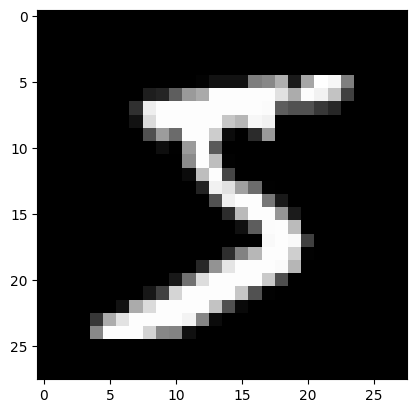

In [ ]:
import matplotlib.pyplot as plt
print(len(mnist_train))     # training dataset 개수 확인

first_data = mnist_train[0]
print(first_data[0].shape)  # 첫번째 data의 형상 확인
print(first_data[1])        # 첫번째 data의 정답 확인
# 첫번째 데이터의 이미지 데이터와 정답 데이터가 따로 되어 있어서 배열의 위치가 다른 것이다.

plt.imshow(first_data[0][0,:,:], cmap='gray')
plt.show()

In [ ]:
first_img = first_data[0]
print(first_img.shape)

#view는 2D를 1D로 평탄화 하기 위해 사용하는 메서드
first_img = first_img.view(-1, 28*28) # 이미지 평탄화 수행 2D -> 1D
print(first_img.shape)

torch.Size([1, 28, 28])
torch.Size([1, 784])


## Single Layer Perceptron 모델 정의

In [ ]:
class SLP (nn.Module):
  def __init__ (self):
    super(SLP, self).__init__()

    #SLP의 입력은 784개, 출력은 10개
    self.fc = nn.Linear(in_features=784, out_features=10)
    #torch.nn.Linear = Fully connected layer

  def forward(self, x):
    #이미지 평탄화
    x = x.view(-1, 28*28)
    y = self.fc(x)

    return y

## Hyper-parameters 지정

In [ ]:
batch_size = 100
learning_rate = 0.1
training_epochs = 15
#torch.nn.CrossEntropyLoss() - 예측값에 대해 자동으로 softmax 적용 , 정답 값과 예측값을 이용해 cross entropy loss 측정
loss_function = nn.CrossEntropyLoss()
network = SLP()
optimizer = torch.optim.SGD(network.parameters(), lr = learning_rate)

#Batch 단위 학습을 위해 DataLoader 함수 사용
data_loader = DataLoader(dataset=mnist_train,
                         batch_size=batch_size,
                         shuffle=True,
                         drop_last=True)

## Perception 학습을 위한 반복문 선언

In [ ]:
for epoch in range(training_epochs): #전체 데이터에 대한 반복 - epoch
  avg_cost = 0
  total_batch = len(data_loader)

  for img, label in data_loader:

    #입력 이미지에 대해 forward pass
    pred = network(img)

    #loss_function은 예측값 pred와 실제 레이블 label 간의 차이를 계산하여 손실 값을 반환, 이 손실 값은 모델의 성능을 평가하는 데 사용
    loss = loss_function(pred, label)
    optimizer.zero_grad() # gradient 초기화
    #모든 weight에 대해 편미분 값 계산
    loss.backward()
    #파라미터 업데이트
    optimizer.step()

    #모든 배치에 대한 평균 loss 값 계산
    avg_cost += loss / total_batch

  print('Epoch: %d Loss = %f'%(epoch+1, avg_cost))

print('Learning finished')

/tmp/ipykernel_2978/3288642445.py:21: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('Epoch: %d Loss = %f'%(epoch+1, avg_cost))


Epoch: 1 Loss = 0.533764
Epoch: 2 Loss = 0.358779
Epoch: 3 Loss = 0.331108
Epoch: 4 Loss = 0.316332
Epoch: 5 Loss = 0.306795
Epoch: 6 Loss = 0.300178
Epoch: 7 Loss = 0.294800
Epoch: 8 Loss = 0.290634
Epoch: 9 Loss = 0.287446
Epoch: 10 Loss = 0.284396
Epoch: 11 Loss = 0.281953
Epoch: 12 Loss = 0.279577
Epoch: 13 Loss = 0.277391
Epoch: 14 Loss = 0.275962
Epoch: 15 Loss = 0.274255
Learning finished


## 학습이 완료된 모델을 이용해 정답률 확인

In [ ]:
with torch.no_grad(): # test에서는 기울기 계산 제외

  img_test = mnist_test.data.float()
  label_test = mnist_test.targets

  prediction = network(img_test) # 전체 test data를 한번에 계산

  #예측 값이 가장 높은 숫자의 정답데이터가 일치한 지 확인
  correct_prediction = torch.argmax(prediction, 1) == label_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy:', accuracy.item())

Accuracy: 0.8913999795913696


## Weight parameter 저장하기/불러오기

In [ ]:
torch.save(network.state_dict(), "./slp_mnist.pth")
